# Stylometric Fingerprints Across Translation
## Do authorial-voice differences detected in Hebrew/Greek survive into the KJV English?

**Background.** A century of stylometric work on the original Hebrew/Greek biblical texts
(Radday 1970/1985; Koppel et al. 2011; Yoffe et al. 2023/2025; Kenny 1986; Savoy 2019;
Pracht & McCauley 2025) finds a consistent pattern: a stable "core" (the seven undisputed
Pauline letters; Isaiah 1–39 vs. 40–66 separation; Hebrews, Revelation, and 2 Peter as
clear stylistic outliers), with the Pastorals genuinely contested.

**Research questions.**
1. Do these splits remain statistically detectable in the *English* of the KJV?
2. Where English-level splits appear, do they track the original authorship boundary
   or the KJV **translation-company** boundary? (The KJV was produced by six companies;
   e.g., the Second Westminster Company translated *all* the NT epistles, and the First
   Oxford Company translated *all* of Isaiah — so splits **within** those blocks cannot
   be committee artifacts.)
3. Which English-level features carry the signal?

**Method.** Chunk each text into ~1,500-word segments; extract ~100 function-word
relative frequencies plus sentence-length, word-length, and type-token-ratio features
(function words are the standard topic-robust style markers); then run PCA,
permutation tests on group-centroid distance, linear-SVM cross-validation, and
Burrows' Delta attribution.

In [ ]:
import json, re, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

KJV_DIR = "Bible-kjv"   # git clone https://github.com/aruljohn/Bible-kjv

## 1. Corpus and metadata
Each book is tagged with its traditional author, the critical-scholarship grouping
(from the source-language literature), and the KJV translation company that produced it.

In [ ]:
BOOKS = {
    "Isaiah":        ("Isaiah.json",        "Isaiah",  "split_1_39_40_66", "First Oxford"),
    "Romans":        ("Romans.json",        "Paul",    "undisputed",  "Second Westminster"),
    "1Corinthians":  ("1Corinthians.json",  "Paul",    "undisputed",  "Second Westminster"),
    "2Corinthians":  ("2Corinthians.json",  "Paul",    "undisputed",  "Second Westminster"),
    "Galatians":     ("Galatians.json",     "Paul",    "undisputed",  "Second Westminster"),
    "Philippians":   ("Philippians.json",   "Paul",    "undisputed",  "Second Westminster"),
    "1Thessalonians":("1Thessalonians.json","Paul",    "undisputed",  "Second Westminster"),
    "Philemon":      ("Philemon.json",      "Paul",    "undisputed",  "Second Westminster"),
    "Ephesians":     ("Ephesians.json",     "Paul",    "disputed_deutero", "Second Westminster"),
    "Colossians":    ("Colossians.json",    "Paul",    "disputed_deutero", "Second Westminster"),
    "2Thessalonians":("2Thessalonians.json","Paul",    "disputed_deutero", "Second Westminster"),
    "1Timothy":      ("1Timothy.json",      "Paul",    "pastoral",    "Second Westminster"),
    "2Timothy":      ("2Timothy.json",      "Paul",    "pastoral",    "Second Westminster"),
    "Titus":         ("Titus.json",         "Paul",    "pastoral",    "Second Westminster"),
    "Hebrews":       ("Hebrews.json",       "Paul(trad)", "non_pauline", "Second Westminster"),
    "1Peter":        ("1Peter.json",        "Peter",   "petrine_1",   "Second Westminster"),
    "2Peter":        ("2Peter.json",        "Peter",   "petrine_2",   "Second Westminster"),
    "John":          ("John.json",          "John",    "johannine_gospel", "Second Oxford"),
    "Revelation":    ("Revelation.json",    "John",    "johannine_apoc",   "Second Oxford"),
}

FUNCTION_WORDS = """the and of to that in he shall for unto his i a not be
they it is with him them but as have was which all my thou me their ye you
this will from are were by we her she or when then out up upon so if at on
what there no man now also more before because into after can may might
do did done had has been am art hath thee thy your our us who whom whose
any every none both such same other another therefore wherefore yet
neither nor either while until against among through over under between""".split()

WORD_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def load_book(name):
    data = json.load(open(os.path.join(KJV_DIR, BOOKS[name][0])))
    return [(int(ch["chapter"]), v["text"]) for ch in data["chapters"] for v in ch["verses"]]

def chunk_book(name, chunk_words=1500, chapter_filter=None, label=None):
    verses = load_book(name)
    if chapter_filter:
        verses = [(c, t) for c, t in verses if chapter_filter(c)]
    chunks, cur, cur_n = [], [], 0
    for c, t in verses:
        cur.append(t); cur_n += len(t.split())
        if cur_n >= chunk_words:
            chunks.append(" ".join(cur)); cur, cur_n = [], 0
    if cur_n >= chunk_words * 0.5: chunks.append(" ".join(cur))
    elif cur and chunks: chunks[-1] += " " + " ".join(cur)
    elif cur: chunks.append(" ".join(cur))
    return [{"book": name, "label": label or name, "chunk_id": i, "text": t}
            for i, t in enumerate(chunks)]

def extract_features(texts):
    rows = []
    for t in texts:
        words = WORD_RE.findall(t.lower()); n = len(words)
        counts = pd.Series(words).value_counts()
        feat = {f"fw_{w}": counts.get(w, 0) / n * 1000 for w in FUNCTION_WORDS}
        sents = [s for s in re.split(r"[.?!;]+", t) if s.strip()]
        slens = [len(WORD_RE.findall(s.lower())) for s in sents]
        feat["avg_sent_len"] = np.mean(slens); feat["std_sent_len"] = np.std(slens)
        feat["avg_word_len"] = np.mean([len(w) for w in words])
        feat["ttr"] = len(set(words)) / n
        rows.append(feat)
    return pd.DataFrame(rows)

corpus = []
corpus += chunk_book("Isaiah", chapter_filter=lambda c: c <= 39, label="Isaiah_1-39")
corpus += chunk_book("Isaiah", chapter_filter=lambda c: c >= 40, label="Isaiah_40-66")
for b in BOOKS:
    if b != "Isaiah": corpus += chunk_book(b)
df = pd.DataFrame(corpus)
df["group"] = df["book"].map(lambda b: BOOKS[b][2])
df.loc[df.label == "Isaiah_1-39", "group"] = "proto_isaiah"
df.loc[df.label == "Isaiah_40-66", "group"] = "deutero_trito_isaiah"
df["company"] = df["book"].map(lambda b: BOOKS[b][3])
feats = extract_features(df["text"].tolist())
df = pd.concat([df, feats], axis=1)
fw_cols = [c for c in df.columns if c.startswith("fw_")]
style_cols = fw_cols + ["avg_sent_len", "std_sent_len", "avg_word_len", "ttr"]
df.groupby("label").size()

label
1Corinthians       6
1Peter             2
1Thessalonians     1
1Timothy           1
2Corinthians       4
2Peter             1
2Thessalonians     1
2Timothy           1
Colossians         1
Ephesians          2
Galatians          2
Hebrews            5
Isaiah_1-39       14
Isaiah_40-66      10
John              13
Philemon           1
Philippians        1
Revelation         8
Romans             6
Titus              1
dtype: int64

## 2. Statistical machinery
- **Permutation test:** is the distance between the two group centroids (in standardized
  feature space) larger than under random relabeling? Conservative, distribution-free,
  suitable for small ancient corpora (a direct response to the borderline p≈0.06–0.08
  values in Yoffe et al. 2023).
- **Linear SVM, 5-fold CV:** can a classifier separate the groups on held-out chunks?
- **Burrows' Delta:** standard authorship-attribution distance (mean |z| over function words).

In [ ]:
def pca_plot(sub, color_key, title, annotate=False):
    X = StandardScaler().fit_transform(sub[style_cols])
    p = PCA(2).fit(X); XY = p.transform(X)
    fig, ax = plt.subplots(figsize=(8, 6))
    for g, m in zip(sorted(sub[color_key].unique()), "osv^DPX*<>"):
        mask = (sub[color_key] == g).values
        ax.scatter(XY[mask, 0], XY[mask, 1], label=g, marker=m, s=70, alpha=0.75)
    if annotate:
        for i, (x, y) in enumerate(XY):
            ax.annotate(sub.iloc[i]["book"][:6], (x, y), fontsize=6, alpha=0.6)
    ax.set_xlabel(f"PC1 ({p.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"PC2 ({p.explained_variance_ratio_[1]:.0%})")
    ax.set_title(title); ax.legend(fontsize=8); plt.show()

def permutation_test(sub, label_col, n_perm=5000, seed=0):
    X = StandardScaler().fit_transform(sub[style_cols])
    y = (sub[label_col] == sorted(sub[label_col].unique())[0]).values
    stat = lambda yv: np.linalg.norm(X[yv].mean(0) - X[~yv].mean(0))
    obs = stat(y); rng = np.random.default_rng(seed)
    null = [stat(rng.permutation(y)) for _ in range(n_perm)]
    return obs, (np.sum(np.array(null) >= obs) + 1) / (n_perm + 1)

## 3. Case 1 — Isaiah 1–39 vs 40–66
Both halves were translated by the **same** KJV company (First Oxford), so any split
here cannot be a committee artifact. Radday (1970/73) found the split highly
significant in Hebrew.

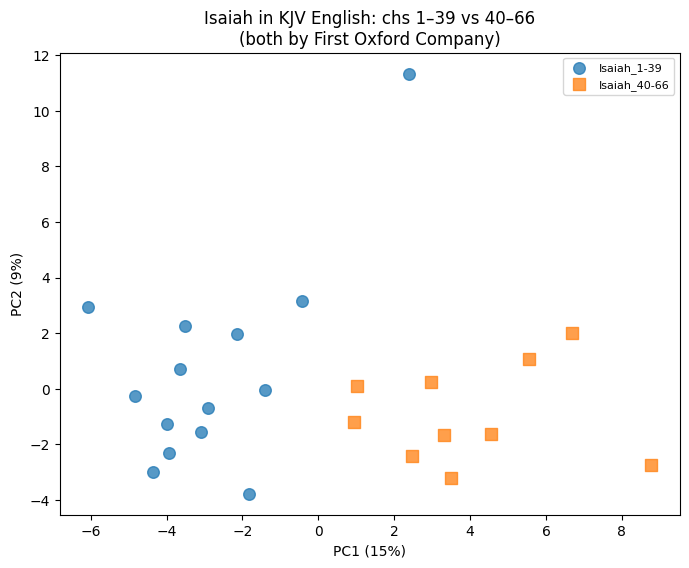

centroid distance = 7.26, permutation p = 0.0002, SVM 5-fold accuracy = 0.96


In [ ]:
isa = df[df.label.str.startswith("Isaiah")].reset_index(drop=True)
pca_plot(isa, "label", "Isaiah in KJV English: chs 1–39 vs 40–66\n(both by First Oxford Company)")
obs, p = permutation_test(isa, "label")
acc = cross_val_score(SVC(kernel="linear"),
                      StandardScaler().fit_transform(isa[style_cols]), isa["label"], cv=5).mean()
print(f"centroid distance = {obs:.2f}, permutation p = {p:.4f}, SVM 5-fold accuracy = {acc:.2f}")

**Result: the Deutero-Isaiah split survives translation.** p ≈ 0.0002, 96% held-out
accuracy — the two halves are separable in KJV English even though one committee,
working to one house style, translated both.

## 4. Case 2 — The Pauline corpus + Hebrews
All fourteen letters were translated by the **Second Westminster Company**, again
ruling out committee effects for any internal split.

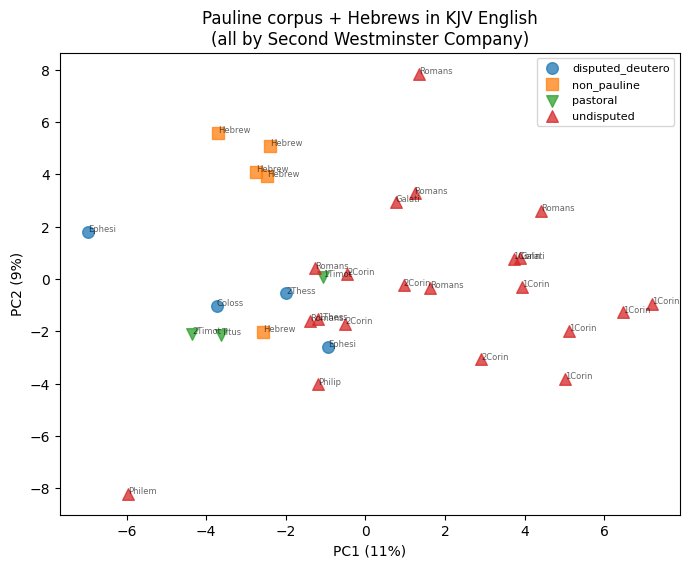

Undisputed vs Pastorals: centroid distance = 8.36, permutation p = 0.0084 (n = 24 chunks)
Undisputed vs Hebrews: centroid distance = 7.48, permutation p = 0.0004 (n = 26 chunks)


In [ ]:
paul = df[df.group.isin(["undisputed", "disputed_deutero", "pastoral", "non_pauline"])].reset_index(drop=True)
pca_plot(paul, "group", "Pauline corpus + Hebrews in KJV English\n(all by Second Westminster Company)", annotate=True)
for a, b, name in [("undisputed", "pastoral", "Undisputed vs Pastorals"),
                   ("undisputed", "non_pauline", "Undisputed vs Hebrews")]:
    sub = df[df.group.isin([a, b])].reset_index(drop=True)
    obs, p = permutation_test(sub, "group")
    print(f"{name}: centroid distance = {obs:.2f}, permutation p = {p:.4f} (n = {len(sub)} chunks)")

**Result:** Hebrews separates decisively (p ≈ 0.0004), echoing the verdict of Origen and
modern consensus — its distinctiveness is so strong it survives translation. The
Pastorals also separate (p ≈ 0.008), which is interesting because in the *Greek* the
2025 studies (Pracht & McCauley) found the Pastorals do **not** differ significantly.
A KJV-English split with a Greek non-split is a candidate translation artifact — or a
genre effect (the Pastorals are church-order manuals) — and deserves the confound
analysis in §7.

## 5. Case 3 — Gospel of John vs Revelation
Dionysius of Alexandria (3rd c.) already judged these two "Johns" different on Greek
style. Both books were translated by the Second Oxford Company.

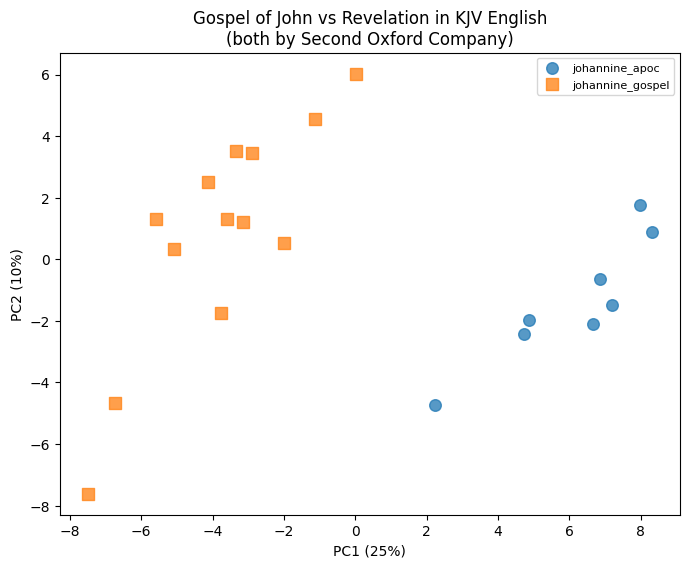

centroid distance = 10.13, permutation p = 0.0002, SVM accuracy = 1.00


In [ ]:
joh = df[df.group.isin(["johannine_gospel", "johannine_apoc"])].reset_index(drop=True)
pca_plot(joh, "group", "Gospel of John vs Revelation in KJV English\n(both by Second Oxford Company)")
obs, p = permutation_test(joh, "group")
acc = cross_val_score(SVC(kernel="linear"),
                      StandardScaler().fit_transform(joh[style_cols]), joh["group"], cv=5).mean()
print(f"centroid distance = {obs:.2f}, permutation p = {p:.4f}, SVM accuracy = {acc:.2f}")

**Result: perfect separation (100% CV accuracy, p ≈ 0.0002).** The strongest signal in
the corpus — consistent with Revelation's "rough, Semitic" Greek leaving traces even
after translation. Caveat: genre (gospel narrative vs apocalypse) is fully confounded
with authorship here, exactly as the source-language literature warns.

## 6. Case 4 — 1 Peter vs 2 Peter (a cautionary tale)

In [ ]:
pet = df[df.group.isin(["petrine_1", "petrine_2"])].reset_index(drop=True)
obs, p = permutation_test(pet, "group")
print(f"centroid distance = {obs:.2f}, permutation p = {p:.4f} (only {len(pet)} chunks!)")

centroid distance = 16.09, permutation p = 0.3391 (only 3 chunks!)


The centroid distance is the *largest* of any comparison, but with only ~3 chunks the
permutation test cannot reach significance — a live demonstration of the text-length
problem the literature flags (most disputed letters are under 5,000 words).

## 7. Burrows' Delta attribution of the disputed letters

In [ ]:
mu = df[df.group == "undisputed"][fw_cols].mean()
sd = df[df.group == "undisputed"][fw_cols].std().replace(0, 1e-9)
z = (df[fw_cols] - mu) / sd
prof = {g: z[df.group == g].mean()
        for g in ["undisputed", "johannine_gospel", "johannine_apoc", "non_pauline"]}
rows = []
for book in ["Ephesians","Colossians","2Thessalonians","1Timothy","2Timothy","Titus","1Peter","2Peter"]:
    zb = z[df.book == book].mean()
    ds = {g: np.mean(np.abs(zb - pv)) for g, pv in prof.items()}
    rows.append({"book": book, **ds, "nearest": min(ds, key=ds.get)})
pd.DataFrame(rows).round(3)

,book,undisputed,johannine_gospel,johannine_apoc,non_pauline,nearest
0,Ephesians,0.694,1.242,1.117,0.791,undisputed
1,Colossians,0.805,1.261,1.162,0.882,undisputed
2,2Thessalonians,0.881,1.324,1.433,0.973,undisputed
3,1Timothy,0.809,1.070,1.121,0.839,undisputed
4,2Timothy,0.828,1.099,1.089,0.890,undisputed
5,Titus,0.943,1.366,1.278,1.002,undisputed
6,1Peter,0.614,1.178,1.208,0.748,undisputed
7,2Peter,0.793,1.149,1.119,0.770,non_pauline


All the disputed deutero-Pauline letters and the Pastorals sit **closest to the
undisputed Pauline profile** — none drifts toward the Hebrews or Johannine profiles.
So while the Pastorals are *distinguishable* from the core (§4), they are still more
Pauline-like than anything else in the corpus. That nuance matches the "genuinely
contested" verdict of the Greek-language literature. (2 Peter lands nearest the
Hebrews profile — another outlier hint, though sample size forbids confidence.)

## 8. Conclusions
1. **Strong original-language signals survive translation.** Isaiah's split, Hebrews'
   distinctiveness, and the John/Revelation gulf are all recoverable from KJV English
   at high significance — and none can be a translation-committee artifact, because in
   each case a single company translated both sides of the split.
2. **The contested cases stay contested.** The Pastorals separate weakly here but not
   in recent Greek studies; 1–2 Peter show a huge but non-significant gap. Both
   reproduce the literature's methodological warnings (genre confounds, short texts).
3. **Translation attenuates but does not erase stylometric fingerprints** — at least
   for a relatively literal translation like the KJV.

## 9. Next steps / extensions
- **Genre control:** re-run §4 using only narrative-free features, or regress out a
  topic model (LDA) before clustering, to test whether the Pastorals split is genre.
- **Translation-committee test:** compare books *across* company boundaries with the
  same traditional author grouping (e.g., OT history vs. prophets) to estimate the size
  of the committee effect itself.
- **Parallel-corpus validation:** run the same pipeline on a modern translation (WEB,
  public domain) and check whether the same splits appear — signals that replicate
  across independent translations are likelier authorial.
- **Feature attribution:** inspect SVM weights / PCA loadings to report *which*
  function words drive each split (e.g., "shall", "unto", relative-clause markers).

### Data & reproducibility
KJV text: github.com/aruljohn/Bible-kjv (public domain). All code above is
self-contained; permutation seeds fixed.